In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# Check PyTorch is working
print(f"PyTorch version: {torch.__version__}")
print(f"MPS available (Apple Silicon GPU): {torch.backends.mps.is_available()}")

# Set device — MPS is Apple's GPU, faster than CPU for neural networks
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.12.0
MPS available (Apple Silicon GPU): True
Using device: mps


In [4]:
epochs_balanced = np.load('/Users/petra/seizure-detection/data/epochs_balanced.npy')
labels_balanced = np.load('/Users/petra/seizure-detection/data/labels_balanced.npy')

print(f"Epochs shape: {epochs_balanced.shape}")
print(f"Labels shape: {labels_balanced.shape}")
print(f"Class balance: {labels_balanced.sum()} ictal, {(labels_balanced==0).sum()} interictal")

Epochs shape: (40, 23, 512)
Labels shape: (40,)
Class balance: 20 ictal, 20 interictal


In [5]:
# --- Dataset ---
class EEGDataset(Dataset):
    """
    Wraps numpy epochs and labels into a PyTorch Dataset.
    Each item is one 2-second epoch and its label.
    """
    def __init__(self, epochs, labels):
        # Convert numpy arrays to PyTorch tensors
        self.X = torch.tensor(epochs, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        # How many epochs in the dataset
        return len(self.y)

    def __getitem__(self, idx):
        # Return one epoch and its label by index
        return self.X[idx], self.y[idx]


# --- Test it ---
dataset = EEGDataset(epochs_balanced, labels_balanced)
print(f"Dataset size: {len(dataset)}")
print(f"Single epoch shape: {dataset[0][0].shape}")
print(f"Single label: {dataset[0][1]}")

Dataset size: 40
Single epoch shape: torch.Size([23, 512])
Single label: 0.0


In [6]:
# --- 1D CNN Model ---
class SeizureCNN(nn.Module):
    def __init__(self, n_channels=23, n_samples=512):
        super(SeizureCNN, self).__init__()

        # First convolutional block
        # Detects local patterns like spike shapes and rhythmic bursts
        self.conv1 = nn.Sequential(
            nn.Conv1d(
                in_channels=n_channels,   # 23 EEG channels
                out_channels=32,          # 32 different pattern detectors
                kernel_size=16,           # looks at 16 samples at a time (~62ms)
                padding=8                 # keeps output same length as input
            ),
            nn.ReLU(),                    # nonlinearity — ignore negative values
            nn.MaxPool1d(kernel_size=4)   # compress time dimension by 4x
        )

        # Second convolutional block
        # Detects higher-level patterns built from the first layer's features
        self.conv2 = nn.Sequential(
            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=8,
                padding=4
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4)
        )

        # Calculate the size after convolutions and pooling
        # 512 samples → after pool1: 128 → after pool2: 32
        # 64 filters × 32 time steps = 2048
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32, 64),   # fully connected layer
            nn.ReLU(),
            nn.Dropout(0.5),           # randomly zero 50% of neurons during training
            nn.Linear(64, 1),          # single output neuron
            nn.Sigmoid()               # squish to 0-1 probability
        )

    def forward(self, x):
        # x shape: (batch, 23 channels, 512 samples)
        x = self.conv1(x)   # → (batch, 32, 128)
        x = self.conv2(x)   # → (batch, 64, 32)
        x = self.fc(x)      # → (batch, 1)
        return x.squeeze(1) # → (batch,)


# Test the model with a dummy input
model = SeizureCNN().to(device)
dummy = torch.randn(8, 23, 512).to(device)  # fake batch of 8 epochs
output = model(dummy)
print(f"Model output shape: {output.shape}")  # should be (8,)
print(f"Output values (should be 0-1): {output[:3].detach().cpu().numpy().round(3)}")
print(f"\nModel architecture:")
print(model)

Model output shape: torch.Size([8])
Output values (should be 0-1): [0.493 0.452 0.512]

Model architecture:
SeizureCNN(
  (conv1): Sequential(
    (0): Conv1d(23, 32, kernel_size=(16,), stride=(1,), padding=(8,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(8,), stride=(1,), padding=(4,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [7]:
# --- Training with Cross Validation ---
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

def train_model(model, train_loader, optimizer, criterion, device):
    """One full pass through the training data."""
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # 1. Forward pass — get predictions
        predictions = model(X_batch)

        # 2. Compute loss — how wrong are we?
        loss = criterion(predictions, y_batch)

        # 3. Backward pass — compute gradients
        optimizer.zero_grad()  # clear gradients from last step
        loss.backward()        # compute new gradients

        # 4. Update weights
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)


def evaluate_model(model, loader, device):
    """Evaluate model on a dataset, return predictions and true labels."""
    model.eval()  # turn off dropout during evaluation
    all_preds = []
    all_labels = []

    with torch.no_grad():  # don't compute gradients during evaluation
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            predictions = model(X_batch)
            # Convert probabilities to binary predictions
            binary_preds = (predictions.cpu().numpy() > 0.5).astype(int)
            all_preds.extend(binary_preds)
            all_labels.extend(y_batch.numpy().astype(int))

    return np.array(all_preds), np.array(all_labels)


# --- Cross Validation Training Loop ---
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_f1_scores = []
train_loss_history = []  # track loss across all folds

X_tensor = torch.tensor(epochs_balanced, dtype=torch.float32)
y_array  = labels_balanced

n_epochs = 50  # number of times to loop through training data

print(f"Training {n_splits}-fold cross validation, {n_epochs} epochs each...")
print("-" * 50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_tensor, y_array)):

    # Split data
    X_train = X_tensor[train_idx]
    y_train = torch.tensor(y_array[train_idx], dtype=torch.float32)
    X_val   = X_tensor[val_idx]
    y_val   = torch.tensor(y_array[val_idx], dtype=torch.float32)

    # Create dataloaders
    train_dataset = EEGDataset(X_train.numpy(), y_train.numpy())
    val_dataset   = EEGDataset(X_val.numpy(),   y_val.numpy())
    train_loader  = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader    = DataLoader(val_dataset,   batch_size=8, shuffle=False)

    # Fresh model and optimizer for each fold
    model     = SeizureCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()  # Binary Cross Entropy Loss

    fold_losses = []

    # Training loop
    for epoch in range(n_epochs):
        loss = train_model(model, train_loader, optimizer, criterion, device)
        fold_losses.append(loss)

    train_loss_history.append(fold_losses)

    # Evaluate on validation set
    preds, labels_val = evaluate_model(model, val_loader, device)
    f1 = f1_score(labels_val, preds, zero_division=0)
    fold_f1_scores.append(f1)

    print(f"Fold {fold+1} — Final loss: {fold_losses[-1]:.4f} | F1: {f1:.3f}")

print("-" * 50)
print(f"Mean F1: {np.mean(fold_f1_scores):.3f} ± {np.std(fold_f1_scores):.3f}")

Training 5-fold cross validation, 50 epochs each...
--------------------------------------------------
Fold 1 — Final loss: 0.6932 | F1: 0.667
Fold 2 — Final loss: 0.6936 | F1: 0.000
Fold 3 — Final loss: 0.7000 | F1: 0.667
Fold 4 — Final loss: 0.6933 | F1: 0.000
Fold 5 — Final loss: 0.6918 | F1: 0.000
--------------------------------------------------
Mean F1: 0.267 ± 0.327


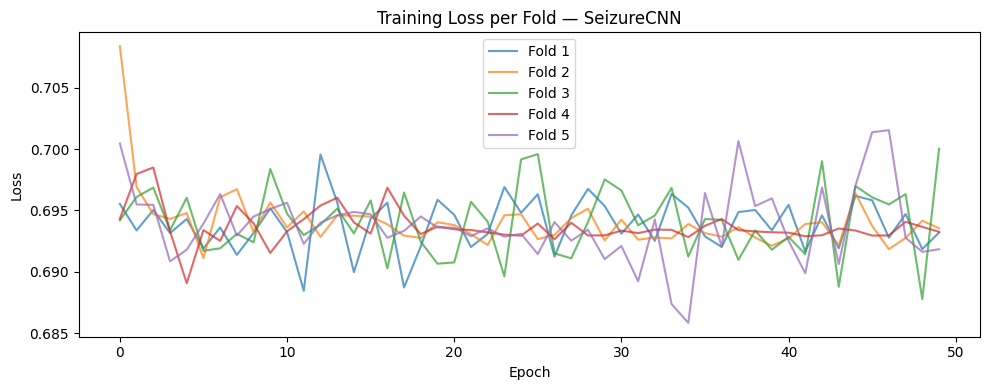

In [8]:
# --- Plot training loss across folds ---
fig, ax = plt.subplots(figsize=(10, 4))

for fold_idx, losses in enumerate(train_loss_history):
    ax.plot(losses, alpha=0.7, label=f'Fold {fold_idx+1}')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss per Fold — SeizureCNN')
ax.legend()
plt.tight_layout()
plt.show()